<a href="https://colab.research.google.com/github/beingAnujChaudhary/DSFS-Joel-Grus/blob/main/notebooks/chapter_03_visualizing_data/experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

# Mount Google Drive (optional)
drive.mount('/content/drive')

# Clone your GitHub repository
!git clone https://github.com/beingAnujChaudhary/DSFS-Joel-Grus.git

# Move into repository
%cd /content/DSFS-Joel-Grus

# Move into Chapter 1 folder
%cd notebooks/chapter_03_visualizing_data

Mounted at /content/drive
Cloning into 'DSFS-Joel-Grus'...
remote: Enumerating objects: 172, done.
remote: Counting objects: 100% (172/172), done.
remote: Compressing objects: 100% (109/109), done.
remote: Total 172 (delta 112), reused 89 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (172/172), 1.22 MiB | 9.04 MiB/s, done.
Resolving deltas: 100% (112/112), done.
/content/DSFS-Joel-Grus
/content/DSFS-Joel-Grus/notebooks/chapter_03_visualizing_data


In [2]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# Set style for cleaner charts
plt.style.use('seaborn-v0_8-whitegrid')

---

# Chapter 3: Visualizing Data — Experiments

## Purpose

This notebook is your playground for experimenting with data visualization concepts introduced in Chapter 3.

The goal is to:
- Explore how visualization choices affect interpretation
- Build intuition for honest, effective chart design
- Modify code freely to test "what if?" scenarios
- Develop first-principles understanding of visual communication
- Ask: *What happens if I change this?* rather than *Let me copy the book.*

**Rule:**
> Do not worry about breaking things. Experimentation is the point. Breaking code is part of learning.


---

## Experiment 1 — Axis Manipulation & Perception

How do axis limits change how viewers interpret data?

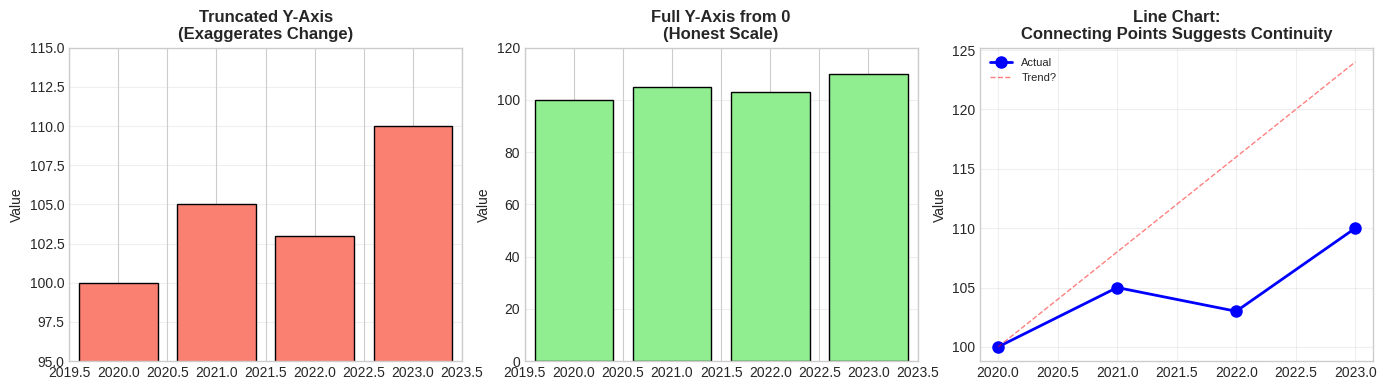

In [3]:
# Same data, different y-axis ranges
years = [2020, 2021, 2022, 2023]
values = [100, 105, 103, 110]  # Small but real growth

plt.figure(figsize=(14, 4))

# 1. Truncated y-axis (exaggerates change)
plt.subplot(1, 3, 1)
plt.bar(years, values, color='salmon', edgecolor='black')
plt.axis([2019.5, 2023.5, 95, 115])  # Truncated
plt.title("Truncated Y-Axis\n(Exaggerates Change)", fontweight='bold')
plt.ylabel("Value")
plt.grid(axis='y', alpha=0.3)

# 2. Full y-axis from 0 (honest scale)
plt.subplot(1, 3, 2)
plt.bar(years, values, color='lightgreen', edgecolor='black')
plt.axis([2019.5, 2023.5, 0, 120])  # Starts at 0
plt.title("Full Y-Axis from 0\n(Honest Scale)", fontweight='bold')
plt.ylabel("Value")
plt.grid(axis='y', alpha=0.3)

# 3. Line chart with different y-axis options
plt.subplot(1, 3, 3)
plt.plot(years, values, 'b-o', linewidth=2, markersize=8, label='Actual')
plt.plot(years, [100, 108, 116, 124], 'r--', linewidth=1, alpha=0.5, label='Trend?')
plt.title("Line Chart:\nConnecting Points Suggests Continuity", fontweight='bold')
plt.ylabel("Value")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 Try modifying:
- Change values to `[100, 200, 150, 300]` and re-run. How does perception change?
- Replace bar chart with line chart: `plt.plot(years, values, marker='o')`. Does a line chart make small changes look more continuous?
- Remove one axis label — does the chart become harder to interpret?
- **Ask yourself:** Which representation would you use for a stakeholder report? For your own analysis?

---

## Experiment 2 — Line Chart Style Variations

How do different line styles, markers, and widths affect readability?


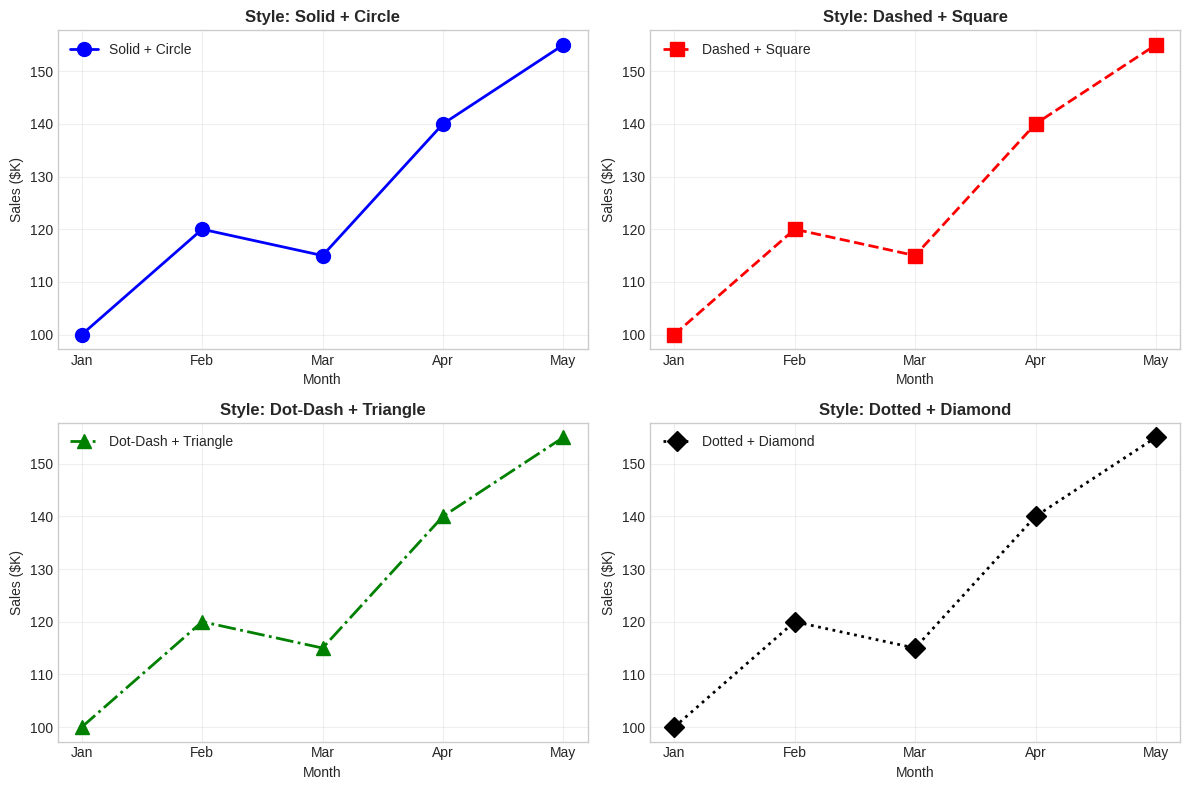

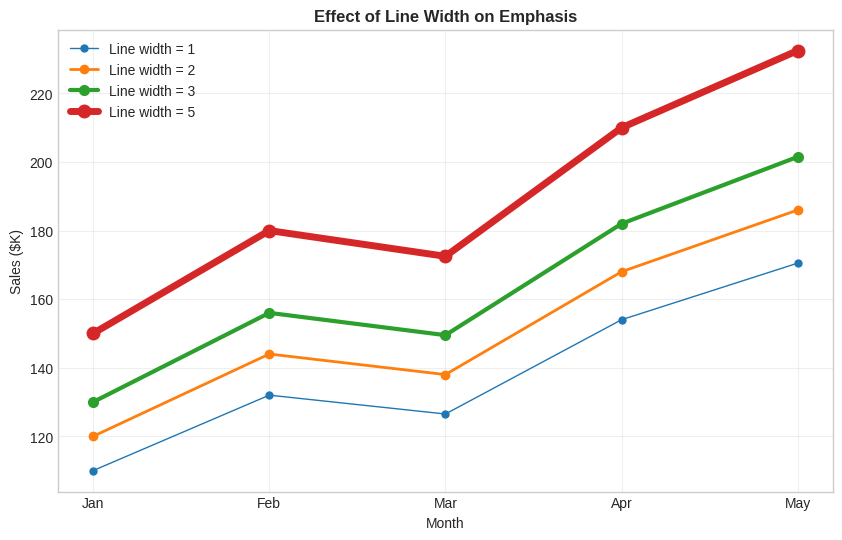

In [4]:
# Compare different line style combinations
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
sales = [100, 120, 115, 140, 155]

styles = [
    ('b-', 'o', 'Solid + Circle'),
    ('r--', 's', 'Dashed + Square'),
    ('g-.', '^', 'Dot-Dash + Triangle'),
    ('k:', 'D', 'Dotted + Diamond'),
]

plt.figure(figsize=(12, 8))

for idx, (line_style, marker, label) in enumerate(styles, start=1):
    plt.subplot(2, 2, idx)
    plt.plot(months, sales, line_style + marker, linewidth=2, markersize=10, label=label)
    plt.title(f"Style: {label}", fontweight='bold')
    plt.xlabel("Month")
    plt.ylabel("Sales ($K)")
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Additional: Compare line widths
plt.figure(figsize=(10, 6))
for width in [1, 2, 3, 5]:
    plt.plot(months, [s * (1 + width * 0.1) for s in sales],
             linewidth=width, marker='o', markersize=width + 4,
             label=f'Line width = {width}')

plt.title("Effect of Line Width on Emphasis", fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Sales ($K)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 💡 Try modifying:
- Combine multiple line styles on one chart with `plt.subplot()`
- Change marker sizes independently from line widths
- **Ask yourself:** When would a dashed line be more appropriate than a solid line?

---

## Experiment 3 — Color, Accessibility & Emotion

How do color choices affect readability and accessibility?


/tmp/ipykernel_15214/487138880.py:37: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_15214/487138880.py:37: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


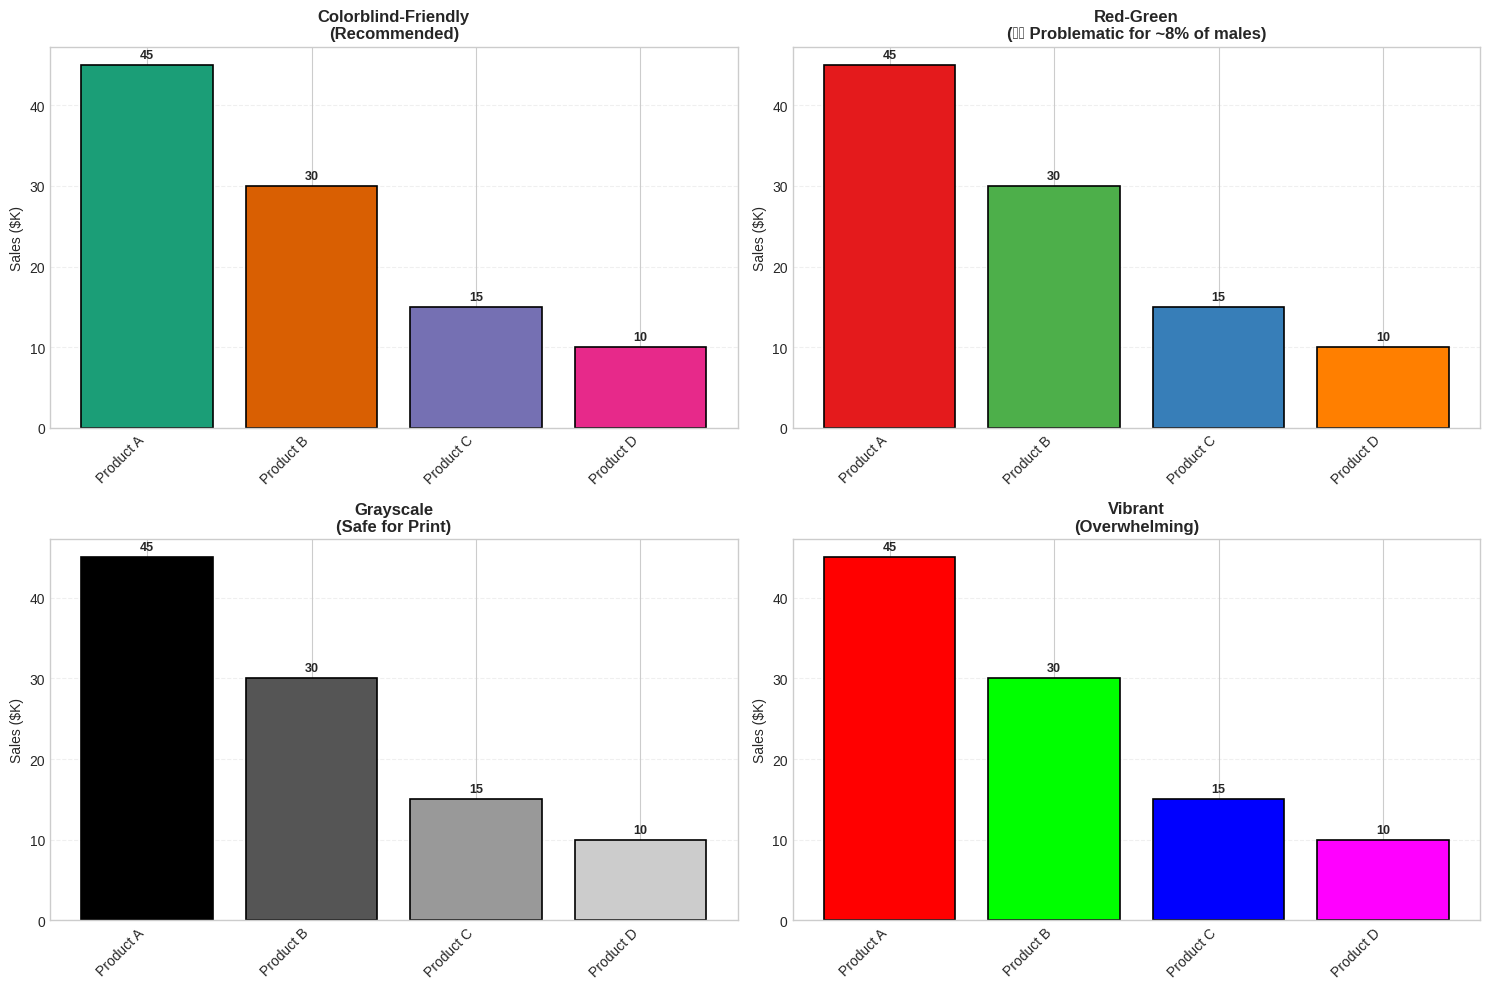

In [5]:
# Compare color schemes for the same data
categories = ['Product A', 'Product B', 'Product C', 'Product D']
sales = [45, 30, 15, 10]

# Colorblind-friendly palette (from ColorBrewer)
cb_friendly = ['#1b9e77', '#d95f02', '#7570b3', '#e7298a']
# Red-green (problematic for colorblind viewers)
red_green = ['#e41a1c', '#4daf4a', '#377eb8', '#ff7f00']
# Grayscale (safe for print, but low contrast)
grayscale = ['#000000', '#555555', '#999999', '#CCCCCC']
# Vibrant (eye-catching but potentially overwhelming)
vibrant = ['#FF0000', '#00FF00', '#0000FF', '#FF00FF']

plt.figure(figsize=(15, 10))

palettes = [
    (cb_friendly, "Colorblind-Friendly\n(Recommended)"),
    (red_green, "Red-Green\n(⚠️ Problematic for ~8% of males)"),
    (grayscale, "Grayscale\n(Safe for Print)"),
    (vibrant, "Vibrant\n(Overwhelming)"),
]

for idx, (colors, title) in enumerate(palettes, start=1):
    plt.subplot(2, 2, idx)
    bars = plt.bar(categories, sales, color=colors, edgecolor='black', linewidth=1.2)
    plt.title(title, fontweight='bold')
    plt.ylabel("Sales ($K)")
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')

    # Add value labels
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height}', ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


### 💡 Try modifying:
- Use `plt.style.available` to test built-in matplotlib styles
- Add patterns (hatching) for print accessibility: `bar.set_hatch('///')`
- Test with a colorblind simulator to see which palettes work best
- **Ask yourself:** Which palette would you choose for a public report? For internal analysis? For a slide deck?

---

## Experiment 4 — Annotation Strategies: Helpful vs Cluttered

When do annotations add value vs create noise?


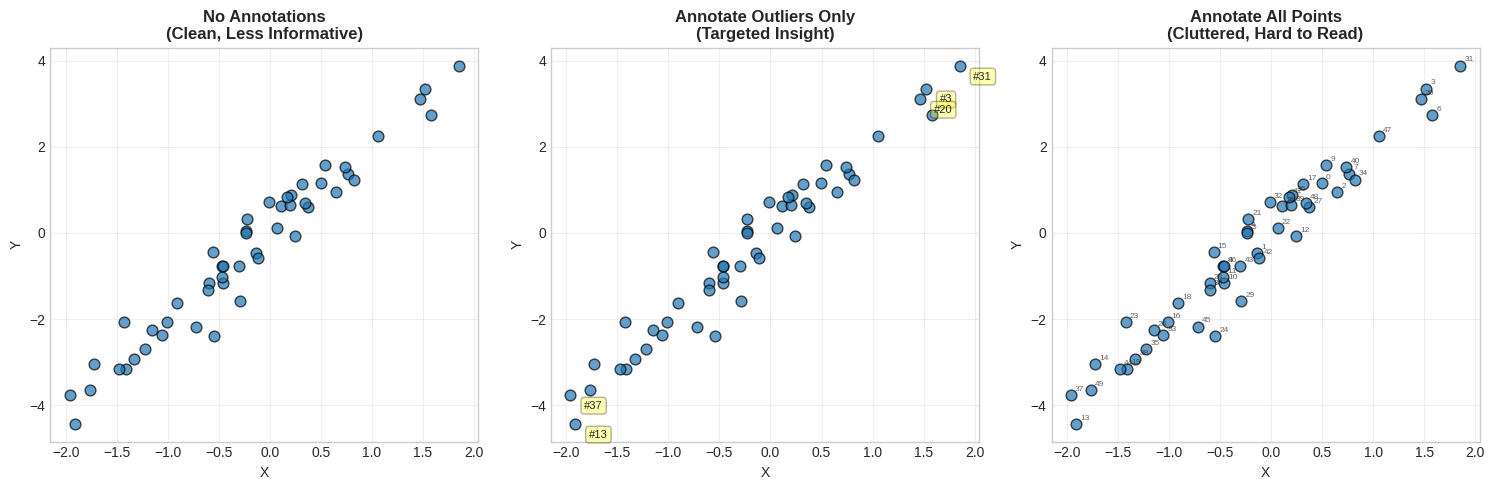

In [6]:
# Scatterplot with different annotation approaches
np.random.seed(42)
x = np.random.randn(50)
y = 2 * x + np.random.randn(50) * 0.5

plt.figure(figsize=(15, 5))

# 1. No annotations (clean but less informative)
plt.subplot(1, 3, 1)
plt.scatter(x, y, alpha=0.7, edgecolors='black', s=60)
plt.title("No Annotations\n(Clean, Less Informative)", fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)

# 2. Annotate outliers only (targeted insight)
plt.subplot(1, 3, 2)
plt.scatter(x, y, alpha=0.7, edgecolors='black', s=60)
# Find points far from mean
distances = np.sqrt((x - x.mean())**2 + (y - y.mean())**2)
outlier_idx = np.where(distances > np.percentile(distances, 90))[0]
for idx in outlier_idx:
    plt.annotate(f'#{idx}', (x[idx], y[idx]),
                xytext=(10, -10), textcoords='offset points',
                fontsize=8, bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))
plt.title("Annotate Outliers Only\n(Targeted Insight)", fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)

# 3. Annotate every point (cluttered and overwhelming)
plt.subplot(1, 3, 3)
plt.scatter(x, y, alpha=0.7, edgecolors='black', s=60)
for i, (xi, yi) in enumerate(zip(x, y)):
    plt.annotate(f'{i}', (xi, yi),
                xytext=(3, 3), textcoords='offset points',
                fontsize=6, alpha=0.7)
plt.title("Annotate All Points\n(Cluttered, Hard to Read)", fontweight='bold')
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### 💡 Try modifying:
- Change annotation offset: `xytext=(5, -5)` vs `xytext=(20, 20)`
- Add arrows to annotations: `arrowprops=dict(arrowstyle='->', color='gray', lw=1)`
- Try different bbox styles: `boxstyle='round'`, `'square'`, `'round4'`
- **Ask yourself:** When would you annotate every point? When is "less is more"?

---

## Experiment 5 — Combining Chart Types for Richer Insights

Can we layer visualizations to show multiple dimensions?


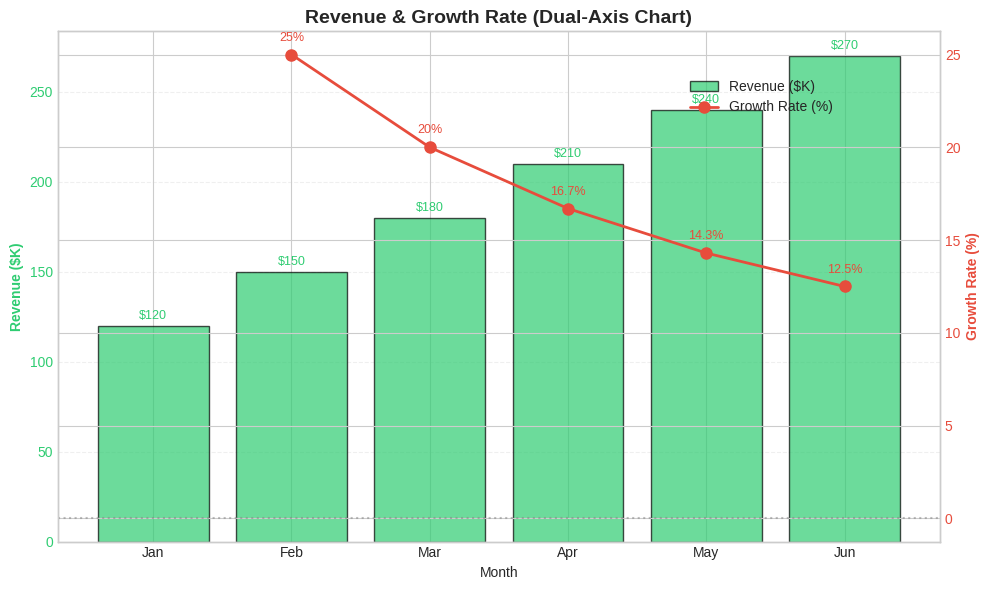

In [7]:
# Combine bar chart + line chart + secondary axis
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
revenue = [120, 150, 180, 210, 240, 270]  # Primary metric
growth_rate = [None, 25, 20, 16.7, 14.3, 12.5]  # Secondary metric (%)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary axis: revenue bars
color1 = '#2ecc71'
bars = ax1.bar(months, revenue, color=color1, alpha=0.7, label='Revenue ($K)', edgecolor='black')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue ($K)', color=color1, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'${height}', ha='center', va='bottom', fontsize=9, color=color1)

# Secondary axis: growth rate line
ax2 = ax1.twinx()
color2 = '#e74c3c'
ax2.plot(months[1:], growth_rate[1:], color=color2, marker='o', linewidth=2,
         markersize=8, label='Growth Rate (%)')
ax2.set_ylabel('Growth Rate (%)', color=color2, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color2)
ax2.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

# Add value labels on line
for i, (month, rate) in enumerate(zip(months[1:], growth_rate[1:])):
    ax2.annotate(f'{rate}%', (month, rate), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9, color=color2)

# Combined title and legend
plt.title("Revenue & Growth Rate (Dual-Axis Chart)", fontsize=14, fontweight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.85, 0.88), fontsize=10)

plt.tight_layout()
plt.show()


### 💡 Try modifying:
- Replace bars with area chart: `ax1.fill_between(range(len(months)), revenue, alpha=0.3)`
- Add a horizontal line for the revenue target
- Invert one axis to show inverse relationships
- **Ask yourself:** When is a dual-axis chart appropriate? When might it mislead?

---

## Experiment 6 — Histogram Bin Size Effects

How does changing the number of bins alter the story?


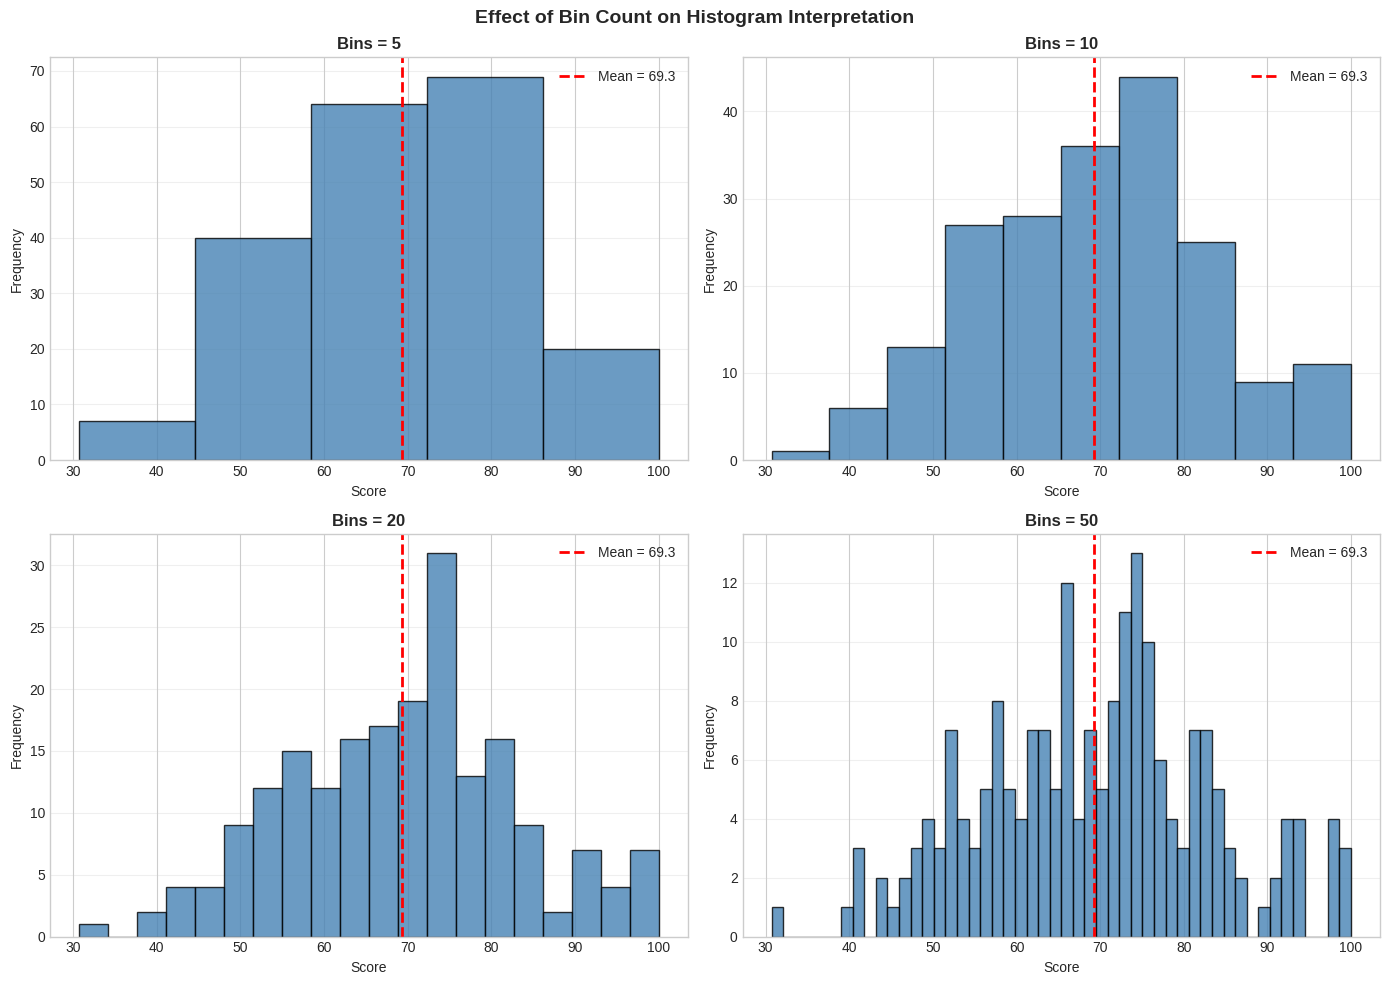

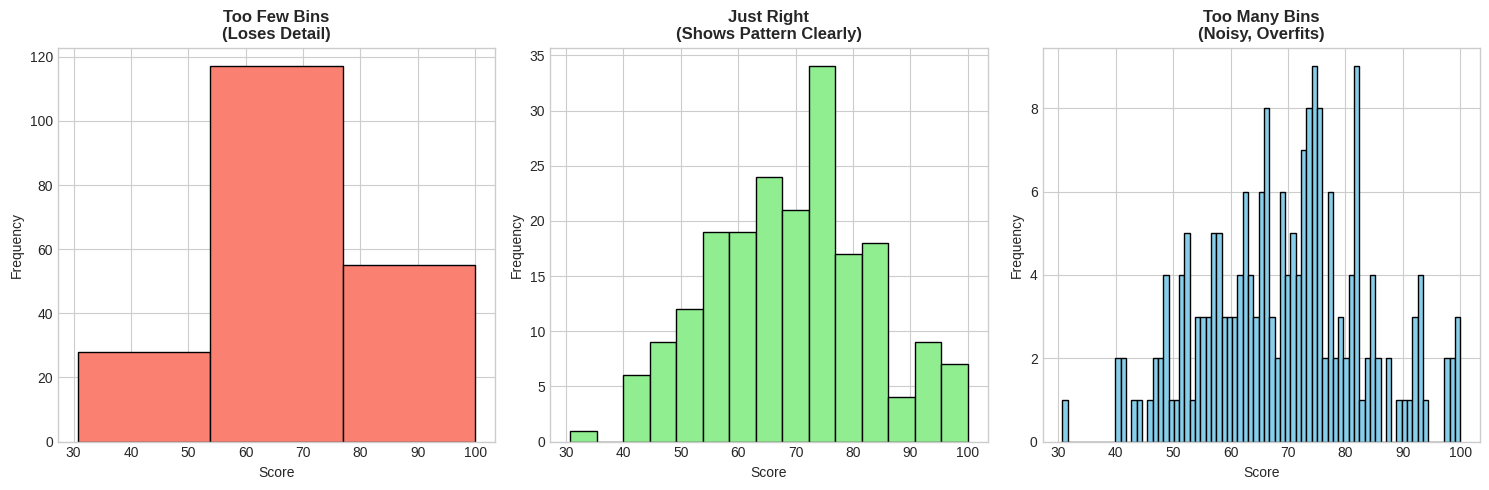

In [8]:
# Same data, different bin counts
np.random.seed(42)
data = np.random.normal(70, 15, 200)  # Exam scores, mean=70, std=15
data = np.clip(data, 0, 100)  # Clip to realistic range

plt.figure(figsize=(14, 10))

bin_options = [5, 10, 20, 50]

for idx, bins in enumerate(bin_options, start=1):
    plt.subplot(2, 2, idx)
    plt.hist(data, bins=bins, color='steelblue', edgecolor='black', alpha=0.8)
    plt.title(f"Bins = {bins}", fontweight='bold', fontsize=12)
    plt.xlabel("Score")
    plt.ylabel("Frequency")
    plt.axvline(x=np.mean(data), color='red', linestyle='--', linewidth=2, label=f'Mean = {np.mean(data):.1f}')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)

plt.suptitle("Effect of Bin Count on Histogram Interpretation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interactive-like comparison: Too few vs Just right vs Too many
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(data, bins=3, color='salmon', edgecolor='black')
plt.title("Too Few Bins\n(Loses Detail)", fontweight='bold')
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(data, bins=15, color='lightgreen', edgecolor='black')
plt.title("Just Right\n(Shows Pattern Clearly)", fontweight='bold')
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.hist(data, bins=75, color='skyblue', edgecolor='black')
plt.title("Too Many Bins\n(Noisy, Overfits)", fontweight='bold')
plt.xlabel("Score")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()



### 💡 Try modifying:
- Use different data distributions: uniform, exponential, bimodal
- Add `alpha=0.5` to overlay multiple histograms
- **Ask yourself:** How do you choose the "right" number of bins for your data?

---

## Experiment 7 — Scatter Plot Matrix (Mini Multi-Panel)

Explore multiple relationships at once with small multiples.



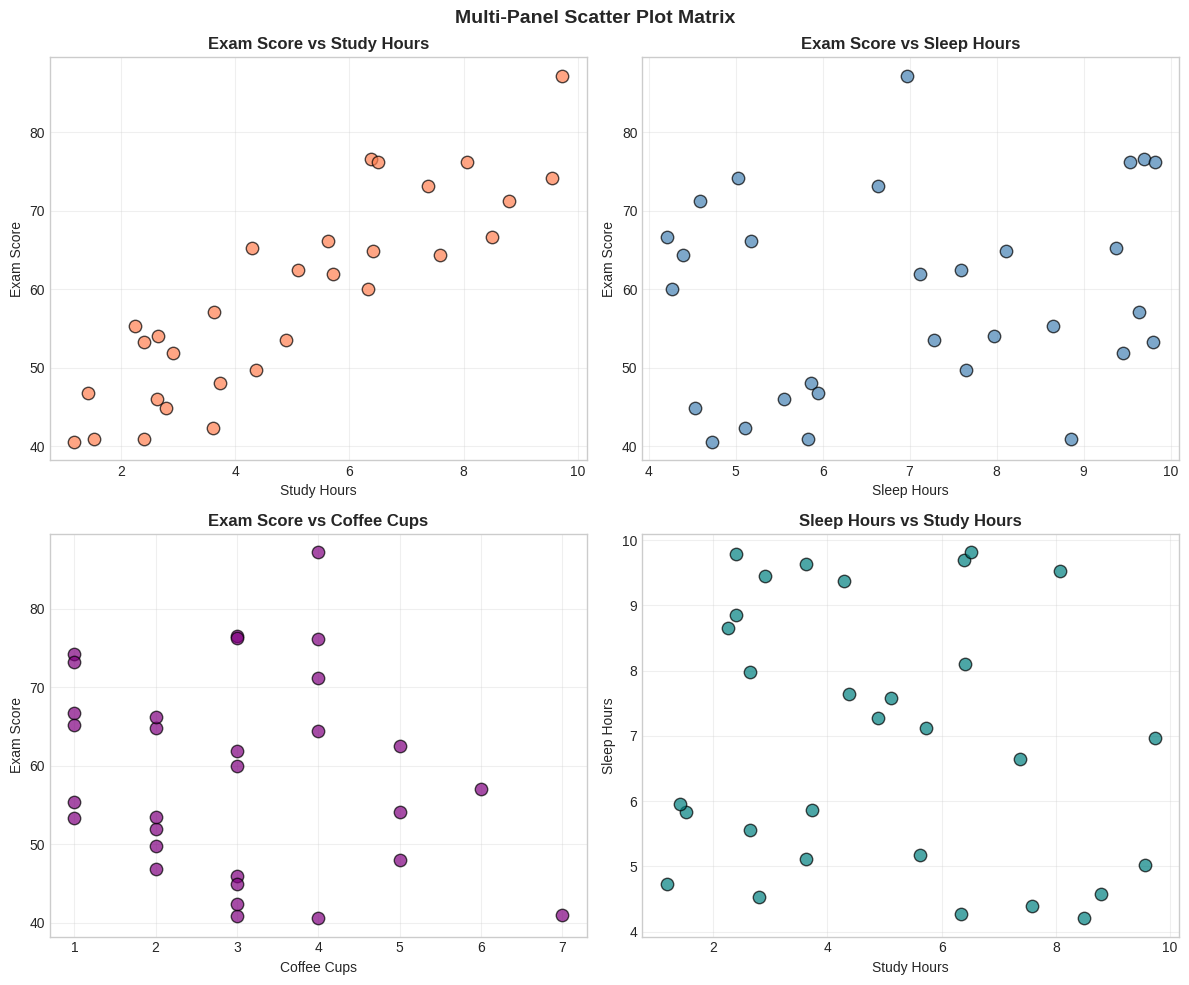

In [9]:
# Create multiple scatter plots to compare different variable pairs
np.random.seed(42)

# Generate related variables
study_hours = np.random.uniform(1, 10, 30)
sleep_hours = np.random.uniform(4, 10, 30)
exam_score = 40 + 5 * study_hours - 2 * (10 - sleep_hours) + np.random.randn(30) * 5
coffee_cups = np.random.poisson(3, 30)

data_pairs = [
    (study_hours, exam_score, "Study Hours", "Exam Score", 'coral'),
    (sleep_hours, exam_score, "Sleep Hours", "Exam Score", 'steelblue'),
    (coffee_cups, exam_score, "Coffee Cups", "Exam Score", 'purple'),
    (study_hours, sleep_hours, "Study Hours", "Sleep Hours", 'teal'),
]

plt.figure(figsize=(12, 10))

for idx, (x, y, xlabel, ylabel, color) in enumerate(data_pairs, start=1):
    plt.subplot(2, 2, idx)
    plt.scatter(x, y, s=80, alpha=0.7, edgecolors='black', color=color)
    plt.title(f"{ylabel} vs {xlabel}", fontweight='bold')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)

plt.suptitle("Multi-Panel Scatter Plot Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### 💡 Try modifying:
- Add a fifth panel showing a different relationship
- Color-code points by a third categorical variable
- Add trend lines using `np.polyfit()`
- **Ask yourself:** How does this compare to a single complex chart with multiple axes?

---

## Experiment 8 — Saving & Exporting Charts

Explore different export formats and resolutions.


✅ Saved charts at different resolutions:
   - sales_low_dpi.png (72 DPI) - Small file, lower quality
   - sales_medium_dpi.png (150 DPI) - Good balance
   - sales_high_dpi.png (300 DPI) - Publication quality
   - sales_vector.pdf - Vector format, infinitely scalable
   sales_low_dpi.png: 11.5 KB
   sales_medium_dpi.png: 28.4 KB
   sales_high_dpi.png: 67.7 KB
   sales_vector.pdf: 21.9 KB


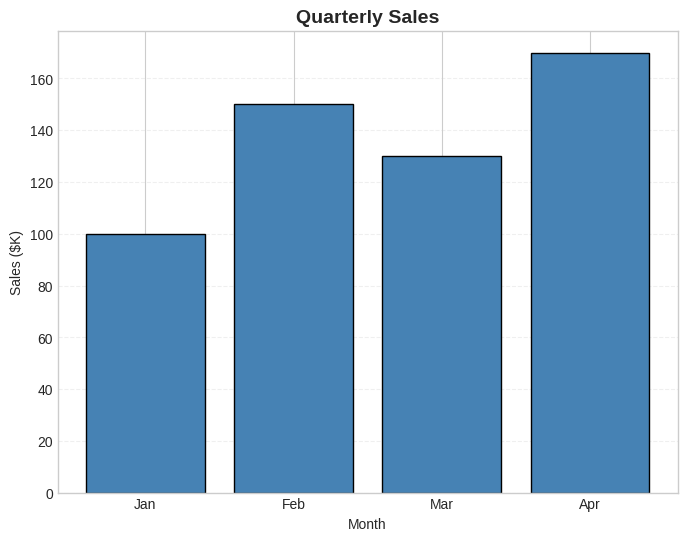

In [10]:
# Compare export quality at different DPI settings
months = ['Jan', 'Feb', 'Mar', 'Apr']
sales = [100, 150, 130, 170]

# Create a polished chart
plt.figure(figsize=(8, 6))
plt.bar(months, sales, color='steelblue', edgecolor='black')
plt.title("Quarterly Sales", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Sales ($K)")
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Save at different DPI
plt.savefig('sales_low_dpi.png', dpi=72, bbox_inches='tight')
plt.savefig('sales_medium_dpi.png', dpi=150, bbox_inches='tight')
plt.savefig('sales_high_dpi.png', dpi=300, bbox_inches='tight')
plt.savefig('sales_vector.pdf', format='pdf', bbox_inches='tight')

print("✅ Saved charts at different resolutions:")
print("   - sales_low_dpi.png (72 DPI) - Small file, lower quality")
print("   - sales_medium_dpi.png (150 DPI) - Good balance")
print("   - sales_high_dpi.png (300 DPI) - Publication quality")
print("   - sales_vector.pdf - Vector format, infinitely scalable")

# Compare file sizes
import os
for filename in ['sales_low_dpi.png', 'sales_medium_dpi.png', 'sales_high_dpi.png', 'sales_vector.pdf']:
    if os.path.exists(filename):
        size_kb = os.path.getsize(filename) / 1024
        print(f"   {filename}: {size_kb:.1f} KB")

plt.show()


### 💡 Try modifying:
- Try `format='svg'` for web-optimized vector graphics
- Compare `bbox_inches='tight'` vs default
- Test transparent backgrounds: `transparent=True`
- **Ask yourself:** When would you use each DPI setting? What format is best for presentations vs reports?

---

## 🔑 Key Takeaways

| Experiment | Insight | Application |
|-----------|---------|-------------|
| Axis manipulation | Truncated axes exaggerate small changes; line charts imply continuity between discrete points | Always start bar charts at 0; be cautious connecting categorical data with lines |
| Line styles | Different styles communicate different emphasis levels | Use solid lines for primary data, dashed/dotted for secondary or projected data |
| Color & accessibility | Colorblind-friendly palettes ensure inclusive communication | Test charts with colorblind simulators; use ColorBrewer for palette selection |
| Annotation strategies | Targeted annotations highlight insights; over-annotation creates noise | Annotate only what matters; use offset + bbox for readability |
| Dual-axis charts | Combining metrics can reveal relationships but misaligned scales can mislead | Use dual axes sparingly; always label units clearly |
| Histogram bins | Too few bins lose detail; too many create noise | Start with ~15-20 bins and adjust based on data size and distribution |
| Small multiples | Multi-panel charts enable comparison without visual overload | Use for exploring multiple variable relationships simultaneously |
| Export quality | DPI and format choice dramatically affect output quality and file size | Use 300 DPI PNG for publications, PDF/SVG for scalable graphics |

---

## 📝 Experimentation Checklist

Use this checklist as you explore each concept:

- [ ] Modified at least one parameter in each experiment
- [ ] Broke something intentionally and observed the result
- [ ] Created at least one completely new chart variation
- [ ] Asked "what if?" at least three times per experiment
- [ ] Documented one surprising finding
- [ ] Saved a chart style you'd use again

---

## 🎨 Pro Experimentation Tips

1. **Break it on purpose**: Set `alpha=0.01` or `axis([0, 1, 1000, 1001])` to see edge cases
2. **Compare side-by-side**: Use `plt.subplot()` to show "before/after" visualizations
3. **Document insights**: Add markdown cells with your observations as you experiment
4. **Save winners**: When you find a great style, save it as a function for reuse:
   ```python
   def professional_bar_chart(x, y, title, xlabel, ylabel):
       # Your polished styling code here
       pass
   ```
5. **Test accessibility**: Run your charts through a colorblind simulator
6. **Consider the audience**: Would this chart work in a presentation? A report? A dashboard?

---

**Next Steps:**
1. Pick one experiment and push it further — combine multiple concepts
2. Create a "visualization checklist" for your future projects based on these experiments

> Remember: The best visualization isn't the prettiest — it's the one that communicates truthfully and efficiently. The curiosity you build here will make you a better data scientist and ML engineer.